In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

from src.graphs import StaticGraph
from src.misc import multi_crx
from qiskit import QuantumCircuit, transpile
import itertools
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import os
import pandas as pd

In [2]:
# Create output directory for plots
output_dir = "trotterization_plots"
os.makedirs(output_dir, exist_ok=True)

# Set up publication-quality plotting style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False  # Set to True if you have LaTeX installed
})

In [3]:
# Initialize global gate count storage
gate_count_data = []

def analyze_and_plot(edges, relabeled_edges, quantum_circuit_builder, title):
    """
    Analyze quantum time evolution errors and plot results
    
    Args:
        edges: Original graph edges
        relabeled_edges: Relabeled graph edges 
        quantum_circuit_builder: Function that builds the quantum circuit
        title: Plot title
    """
    global gate_count_data
    delta_t = 0.1
    n_steps_list = [1, 2, 5, 10, 20, 50, 100]
    
    print(f"\n{title}")
    print("="*60)
    print(f"Original edges: {edges}")
    print(f"Relabeled edges: {relabeled_edges}")
    
    # Display original graph
    G_original = StaticGraph(edges)
    print("\nOriginal Graph:")
    display(G_original.draw())
    
    # Display relabeled graph
    G_relabeled = StaticGraph(relabeled_edges)
    print("Relabeled Graph:")
    display(G_relabeled.draw())
    
    # Display sample quantum circuit (with n_steps=1 for clarity)
    sample_qc = quantum_circuit_builder(G_relabeled.n_qubits, 1, delta_t)
    print("Sample Quantum Circuit (n_steps=1):")
    display(sample_qc.draw('mpl'))
    
    # Initialize storage for errors and gate counts
    matching_vs_exact_errors = []
    pauli_vs_exact_errors = []
    matching_gates_no_opt = []
    matching_gates_opt = []
    pauli_gates_no_opt = []
    pauli_gates_opt = []
    exact_gates_no_opt = []
    exact_gates_opt = []
    
    # Create relabeled graph and get exact solution
    H = G_relabeled.get_adj_mat()
    n_qubits = G_relabeled.n_qubits
    
    exact_op = expm(-1j * H * delta_t)
    exact_operator = Operator(exact_op)
    
    # Pre-calculate Pauli decomposition (this is constant for all n_steps)
    pauli_strings = []
    coeffs = []
    
    # Decompose Hamiltonian into Pauli basis
    for pauli_string in ["".join(p) for p in itertools.product("IXYZ", repeat=n_qubits)]:
        P = Pauli(pauli_string)
        P_op = Operator(P).data
        coeff = np.trace(P_op.conj().T @ H) / (2**n_qubits)
        
        real_coeff = float(np.real(coeff))
        if not np.isclose(real_coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(real_coeff)
    
    # Build exact circuit once for gate counting
    exact_qc = QuantumCircuit(n_qubits)
    exact_qc.unitary(exact_operator, range(n_qubits), label='exact_evolution')
    
    # Transpile exact circuit - no optimization and with optimization
    transpiled_exact_no_opt = transpile(exact_qc, basis_gates=['u3', 'cx'], optimization_level=0)
    transpiled_exact_opt = transpile(exact_qc, basis_gates=['u3', 'cx'], optimization_level=3)
    
    exact_gate_counts_no_opt = transpiled_exact_no_opt.count_ops()
    exact_gate_counts_opt = transpiled_exact_opt.count_ops()
    
    exact_single_no_opt = exact_gate_counts_no_opt.get('u3', 0)
    exact_two_no_opt = exact_gate_counts_no_opt.get('cx', 0)
    exact_single_opt = exact_gate_counts_opt.get('u3', 0)
    exact_two_opt = exact_gate_counts_opt.get('cx', 0)
    
    for n_steps in n_steps_list:
        # Build ACCUMULATED matching-based quantum circuit
        matching_qc = quantum_circuit_builder(n_qubits, n_steps, delta_t)
        
        # SINGLE TRANSPILATION for matching circuit - no optimization and with optimization
        transpiled_matching_no_opt = transpile(matching_qc, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_matching_opt = transpile(matching_qc, basis_gates=['u3', 'cx'], optimization_level=3)
        
        # Get matching operator from optimized version for error calculation
        matching_operator = Operator(transpiled_matching_opt)
        
        # Count gates in matching circuits
        matching_gate_counts_no_opt = transpiled_matching_no_opt.count_ops()
        matching_gate_counts_opt = transpiled_matching_opt.count_ops()
        
        matching_single_no_opt = matching_gate_counts_no_opt.get('u3', 0)
        matching_two_no_opt = matching_gate_counts_no_opt.get('cx', 0)
        matching_single_opt = matching_gate_counts_opt.get('u3', 0)
        matching_two_opt = matching_gate_counts_opt.get('cx', 0)
        
        matching_gates_no_opt.append({'u3': matching_single_no_opt, 'cx': matching_two_no_opt, 
                                     'total': matching_single_no_opt + matching_two_no_opt})
        matching_gates_opt.append({'u3': matching_single_opt, 'cx': matching_two_opt, 
                                  'total': matching_single_opt + matching_two_opt})
        
        # Build ACCUMULATED Pauli circuit
        pauli_qc = QuantumCircuit(n_qubits)
        
        if coeffs:
            dt = delta_t / n_steps
            
            # Build complete accumulated circuit
            for step in range(n_steps):
                for pauli_string, coeff in zip(pauli_strings, coeffs):
                    single_pauli_op = SparsePauliOp([pauli_string], [coeff])
                    evo_gate = PauliEvolutionGate(single_pauli_op, time=dt)
                    pauli_qc.append(evo_gate, range(n_qubits))
        
        # SINGLE TRANSPILATION for accumulated Pauli circuit - no optimization and with optimization
        transpiled_pauli_no_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_pauli_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], optimization_level=3)
        
        # Get Pauli operator from optimized version for error calculation
        pauli_operator = Operator(transpiled_pauli_opt)
        
        # Count gates in Pauli circuits
        pauli_gate_counts_no_opt = transpiled_pauli_no_opt.count_ops()
        pauli_gate_counts_opt = transpiled_pauli_opt.count_ops()
        
        pauli_single_no_opt = pauli_gate_counts_no_opt.get('u3', 0)
        pauli_two_no_opt = pauli_gate_counts_no_opt.get('cx', 0)
        pauli_single_opt = pauli_gate_counts_opt.get('u3', 0)
        pauli_two_opt = pauli_gate_counts_opt.get('cx', 0)
        
        pauli_gates_no_opt.append({'u3': pauli_single_no_opt, 'cx': pauli_two_no_opt, 
                                  'total': pauli_single_no_opt + pauli_two_no_opt})
        pauli_gates_opt.append({'u3': pauli_single_opt, 'cx': pauli_two_opt, 
                               'total': pauli_single_opt + pauli_two_opt})
        
        # Store gate count data for table
        gate_count_data.extend([
            {
                'Case': title,
                'Method': 'Exact',
                'n_steps': n_steps,
                'Optimization': 'No',
                'U3_gates': exact_single_no_opt,
                'CX_gates': exact_two_no_opt,
                'Total_gates': exact_single_no_opt + exact_two_no_opt
            },
            {
                'Case': title,
                'Method': 'Exact',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'U3_gates': exact_single_opt,
                'CX_gates': exact_two_opt,
                'Total_gates': exact_single_opt + exact_two_opt
            },
            {
                'Case': title,
                'Method': 'Matching',
                'n_steps': n_steps,
                'Optimization': 'No',
                'U3_gates': matching_single_no_opt,
                'CX_gates': matching_two_no_opt,
                'Total_gates': matching_single_no_opt + matching_two_no_opt
            },
            {
                'Case': title,
                'Method': 'Matching',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'U3_gates': matching_single_opt,
                'CX_gates': matching_two_opt,
                'Total_gates': matching_single_opt + matching_two_opt
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'No',
                'U3_gates': pauli_single_no_opt,
                'CX_gates': pauli_two_no_opt,
                'Total_gates': pauli_single_no_opt + pauli_two_no_opt
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'U3_gates': pauli_single_opt,
                'CX_gates': pauli_two_opt,
                'Total_gates': pauli_single_opt + pauli_two_opt
            }
        ])
        
        # Calculate errors using optimized circuits
        matching_vs_exact = np.linalg.norm(matching_operator - exact_operator, ord=2)
        pauli_vs_exact = np.linalg.norm(pauli_operator - exact_operator, ord=2)
        
        matching_vs_exact_errors.append(matching_vs_exact)
        pauli_vs_exact_errors.append(pauli_vs_exact)
    
    # Print detailed gate count summary
    print(f"\nDetailed Gate Count Summary for {title}:")
    print("="*120)
    print("n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)")
    print("-"*120)
    for i, n_steps in enumerate(n_steps_list):
        print(f"{n_steps:7d} | {matching_gates_no_opt[i]['u3']:3d}/{matching_gates_no_opt[i]['cx']:3d}/{matching_gates_no_opt[i]['total']:6d}"
              f"              | {matching_gates_opt[i]['u3']:3d}/{matching_gates_opt[i]['cx']:3d}/{matching_gates_opt[i]['total']:6d}"
              f"             | {pauli_gates_no_opt[i]['u3']:3d}/{pauli_gates_no_opt[i]['cx']:3d}/{pauli_gates_no_opt[i]['total']:6d}"
              f"            | {pauli_gates_opt[i]['u3']:3d}/{pauli_gates_opt[i]['cx']:3d}/{pauli_gates_opt[i]['total']:6d}")
    print("="*120)
    
    # # Print optimization savings
    # print(f"\nOptimization Savings for {title}:")
    # print("="*80)
    # print("n_steps | Matching Reduction (%) | Pauli Reduction (%)")
    # print("-"*80)
    # for i, n_steps in enumerate(n_steps_list):
    #     matching_reduction = 100 * (1 - matching_gates_opt[i]['total'] / matching_gates_no_opt[i]['total']) if matching_gates_no_opt[i]['total'] > 0 else 0
    #     pauli_reduction = 100 * (1 - pauli_gates_opt[i]['total'] / pauli_gates_no_opt[i]['total']) if pauli_gates_no_opt[i]['total'] > 0 else 0
    #     print(f"{n_steps:7d} | {matching_reduction:18.1f} | {pauli_reduction:15.1f}")
    # print("="*80)
    
    # Create error analysis plot (skip if title contains "exact")
    if "exact" not in title.lower():
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # Use distinct colors and markers
        ax.loglog(n_steps_list, matching_vs_exact_errors, 'o-', label='Matching-based', 
                  linewidth=2.5, markersize=8, color='#1f77b4', markerfacecolor='white', 
                  markeredgewidth=2, markeredgecolor='#1f77b4')
        ax.loglog(n_steps_list, pauli_vs_exact_errors, 's-', label='Pauli decomposition', 
                  linewidth=2.5, markersize=8, color='#d62728', markerfacecolor='white',
                  markeredgewidth=2, markeredgecolor='#d62728')
        
        ax.set_xlabel('Number of Trotter steps', fontsize=14)
        ax.set_ylabel('2-norm Operator Difference (vs exact CTQW)', fontsize=14)
        # Handle title with or without colon
        plot_title = title.split(":")[1].strip() if ":" in title else title
        ax.set_title(plot_title, fontsize=16, pad=20)
        
        # Customize grid and spines
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Legend with better positioning
        ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
        
        # Tight layout with padding
        plt.tight_layout(pad=1.5)
        
        # Save error analysis plot - derive filename from title
        # Convert title to valid filename
        filename_base = title.lower().replace(" ", "_").replace(":", "").replace("(", "").replace(")", "").replace("-", "_")
        # Remove multiple underscores and clean up
        filename_base = "_".join([part for part in filename_base.split("_") if part])
        filename = f"{output_dir}/{filename_base}_error_analysis.pdf"
        plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
        print(f"Error plot saved as: {filename}")
        
        plt.show()
    else:
        print("Note: Case is exact, so no error analysis is performed.")

def create_gate_count_summary_table():
    """Create a comprehensive summary table of all gate counts"""
    global gate_count_data
    
    if not gate_count_data:
        print("No gate count data available.")
        return
    
    # Convert to DataFrame for easier manipulation
    df = pd.DataFrame(gate_count_data)
    
    # Create summary table
    print("\n" + "="*100)
    print("COMPREHENSIVE GATE COUNT SUMMARY")
    print("="*100)
    
    # Group by case and method
    for case in df['Case'].unique():
        print(f"\nCase: {case}")
        print("-" * 80)
        case_data = df[df['Case'] == case]
        
        for method in ['Exact', 'Matching', 'Pauli']:
            method_data = case_data[case_data['Method'] == method]
            if not method_data.empty:
                print(f"\n{method} Method:")
                print("n_steps | No Opt (U3/CX/Total) | Optimized (U3/CX/Total) | Reduction (%)")
                print("-" * 75)
                
                for n_steps in sorted(method_data['n_steps'].unique()):
                    no_opt = method_data[(method_data['n_steps'] == n_steps) & 
                                       (method_data['Optimization'] == 'No')]
                    opt = method_data[(method_data['n_steps'] == n_steps) & 
                                    (method_data['Optimization'] == 'Yes')]
                    
                    if not no_opt.empty and not opt.empty:
                        no_opt_row = no_opt.iloc[0]
                        opt_row = opt.iloc[0]
                        
                        reduction = 100 * (1 - opt_row['Total_gates'] / no_opt_row['Total_gates']) if no_opt_row['Total_gates'] > 0 else 0
                        
                        print(f"{n_steps:7d} | {no_opt_row['U3_gates']:3d}/{no_opt_row['CX_gates']:3d}/{no_opt_row['Total_gates']:6d}"
                              f"      | {opt_row['U3_gates']:3d}/{opt_row['CX_gates']:3d}/{opt_row['Total_gates']:6d}"
                              f"        | {reduction:8.1f}")
        
        print("-" * 80)


Cycle Graph C4
Original edges: {('10', '11'), ('00', '10'), ('00', '01'), ('01', '11')}
Relabeled edges: {('11', '10'), ('00', '10'), ('01', '00'), ('01', '11')}

Original Graph:


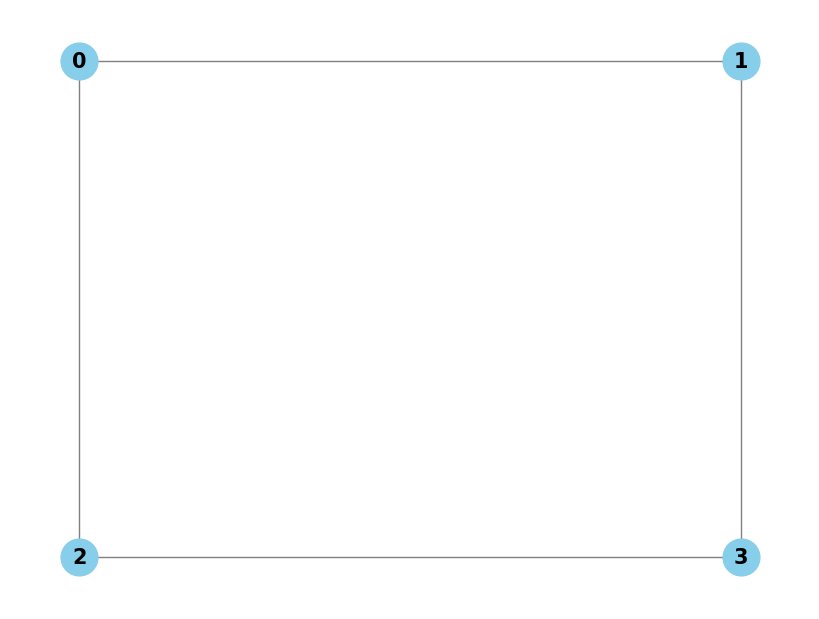

None

Relabeled Graph:


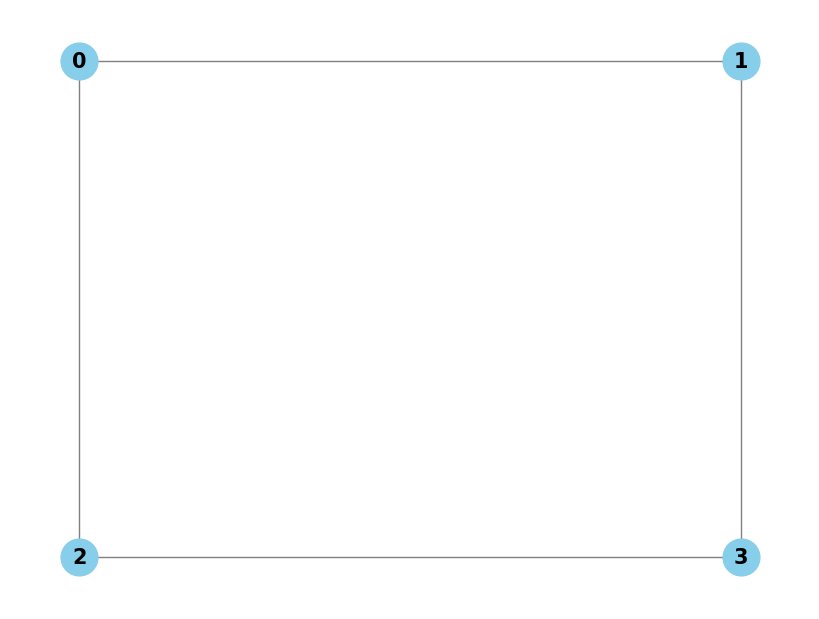

None

Sample Quantum Circuit (n_steps=1):


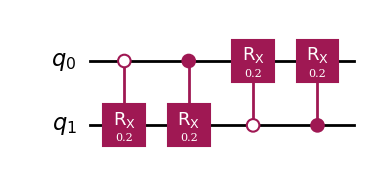


Detailed Gate Count Summary for Cycle Graph C4:
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 |  16/  8/    24              |   2/  0/     2             |   2/  0/     2            |   2/  0/     2
      2 |  32/ 16/    48              |   2/  0/     2             |   4/  0/     4            |   2/  0/     2
      5 |  80/ 40/   120              |   2/  0/     2             |  10/  0/    10            |   2/  0/     2
     10 | 160/ 80/   240              |   2/  0/     2             |  20/  0/    20            |   2/  0/     2
     20 | 320/160/   480              |   2/  0/     2             |  40/  0/    40            |   2/  0/     2
     50 | 800/400/  1200              |   2/  0/     2             | 100/  0/   100            |   2/  0/     2
    100 | 1600/800/  2400         

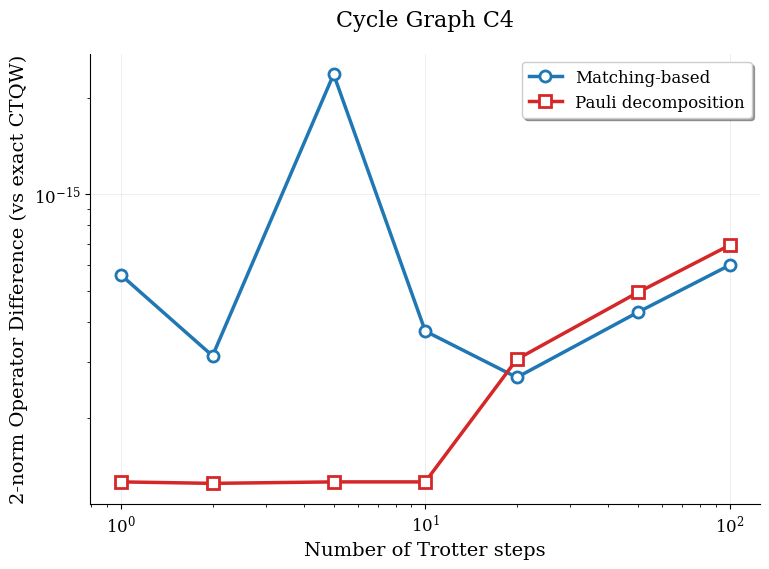

In [4]:
# Test Case 1: Simple 2-qubit system (exact case)
def circuit_builder_1(n_qubits, n_steps, delta_t):
    full_qc = QuantumCircuit(n_qubits)
    for i in range(n_steps):
        # full_qc.rx(2 * delta_t/n_steps, 0)
        # full_qc.rx(2 * delta_t/n_steps, 1)
        mcrx0 = multi_crx(2 * delta_t/n_steps, '0')
        mcrx1 = multi_crx(2 * delta_t/n_steps, '1')
        full_qc.append(mcrx0, [0,1])
        full_qc.append(mcrx1, [0,1])
        full_qc.append(mcrx0, [1,0])
        full_qc.append(mcrx1, [1,0])
    return full_qc

edges_1 = {('00', '10'), ('01', '11'), ('10', '11'), ('00', '01')}
relabeled_edges_1 = {('11', '10'), ('00', '10'), ('01', '11'), ('01', '00')}

analyze_and_plot(edges_1, relabeled_edges_1, circuit_builder_1, "Cycle Graph C4")


Complete Graph K4 - C2
Original edges: {('01', '11'), ('00', '01'), ('01', '10'), ('00', '11'), ('00', '10')}
Relabeled edges: {('11', '10'), ('00', '01'), ('11', '01'), ('01', '10'), ('00', '10')}

Original Graph:


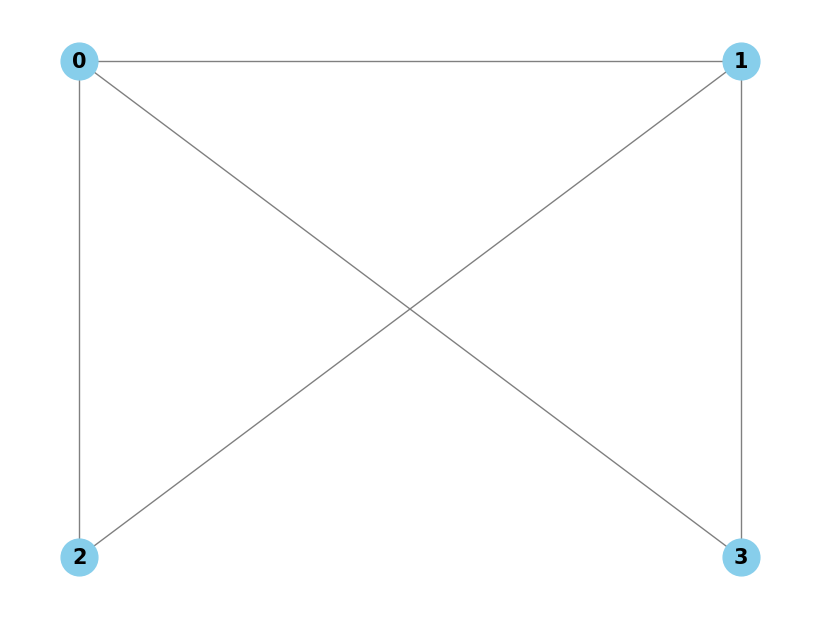

None

Relabeled Graph:


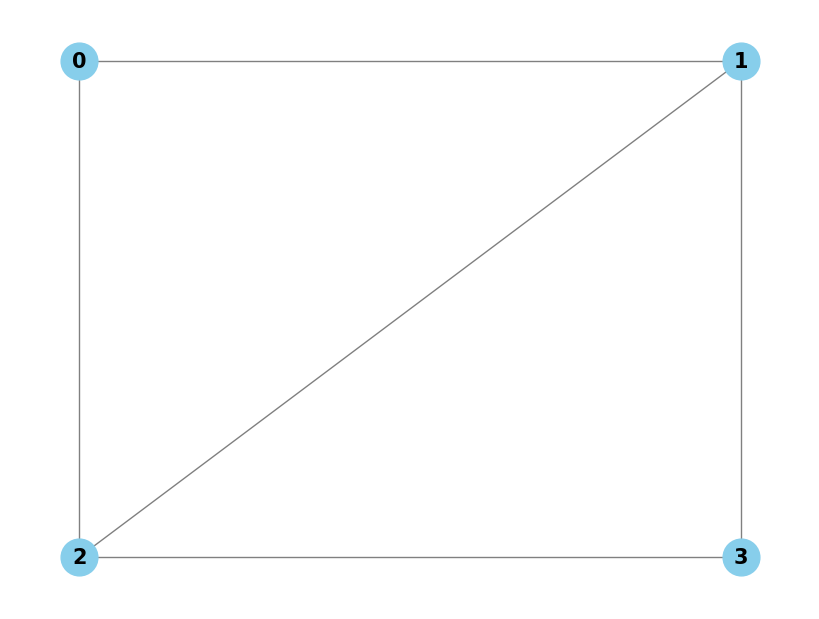

None

Sample Quantum Circuit (n_steps=1):


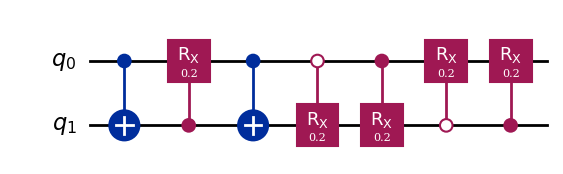


Detailed Gate Count Summary for Complete Graph K4 - C2:
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 |  19/ 12/    31              |   6/  2/     8             |  12/  4/    16            |   6/  2/     8
      2 |  38/ 24/    62              |   8/  3/    11             |  24/  8/    32            |   8/  3/    11
      5 |  95/ 60/   155              |   8/  3/    11             |  60/ 20/    80            |   8/  3/    11
     10 | 190/120/   310              |   8/  3/    11             | 120/ 40/   160            |   8/  3/    11
     20 | 380/240/   620              |   8/  3/    11             | 240/ 80/   320            |   8/  3/    11
     50 | 950/600/  1550              |   8/  3/    11             | 600/200/   800            |   8/  3/    11
    100 | 1900/1200/  3100

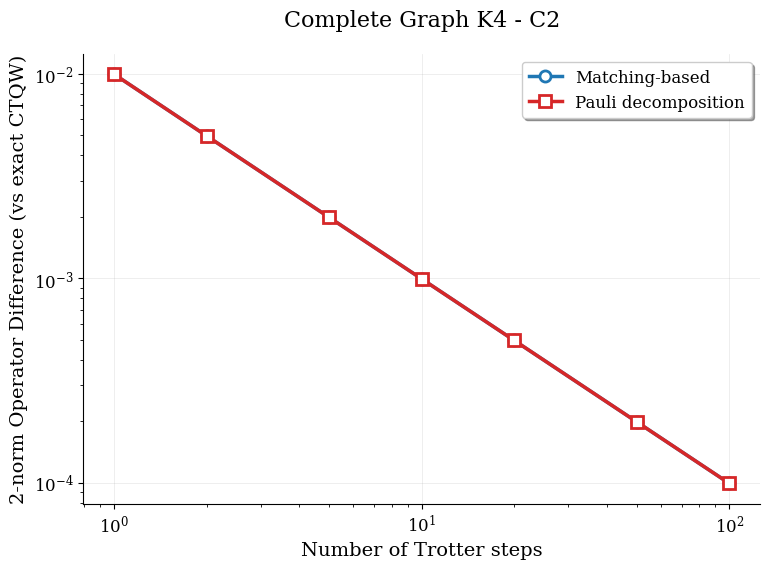

In [5]:
# Test Case 3: Modified CRX without X gates
def circuit_builder_3(n_qubits, n_steps, delta_t):
    full_qc = QuantumCircuit(n_qubits)
    for i in range(n_steps):
        full_qc.cx(0, 1)
        full_qc.crx(2 * delta_t/n_steps, 1, 0)
        full_qc.cx(0, 1)
        mcrx0 = multi_crx(2 * delta_t/n_steps, '0')
        mcrx1 = multi_crx(2 * delta_t/n_steps, '1')
        full_qc.append(mcrx0, [0,1])
        full_qc.append(mcrx1, [0,1])
        full_qc.append(mcrx0, [1,0])
        full_qc.append(mcrx1, [1,0])
    return full_qc

edges_3 = {('00', '11'), ('01', '10'), ('00', '10'), ('01', '11'), ('00', '01')}
relabeled_edges_3 = {('01', '10'), ('00', '10'), ('11', '01'), ('11', '10'), ('00', '01')}

analyze_and_plot(edges_3, relabeled_edges_3, circuit_builder_3, "Complete Graph K4 - C2")


Path Graph P3
Original edges: {('10', '11'), ('01', '10'), ('00', '01')}
Relabeled edges: {('10', '11'), ('01', '00'), ('00', '10')}

Original Graph:


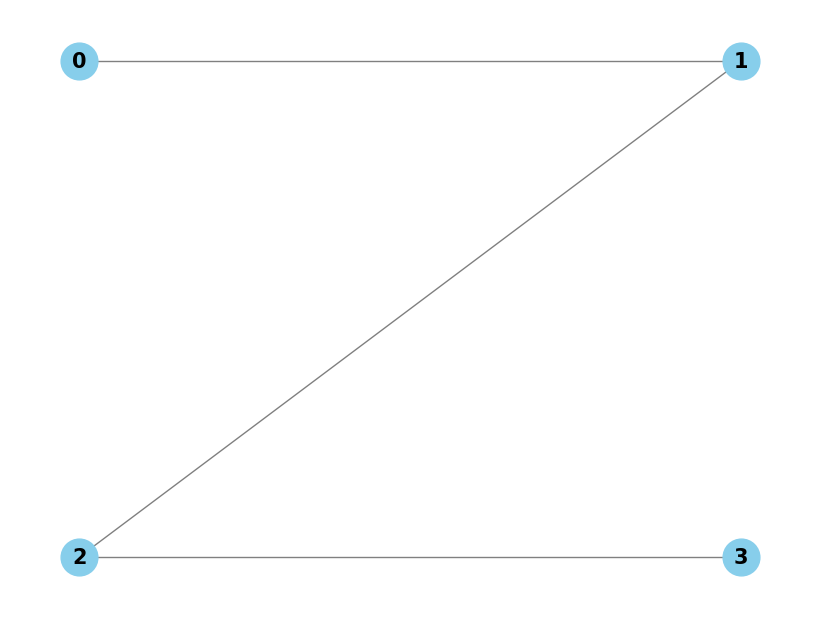

None

Relabeled Graph:


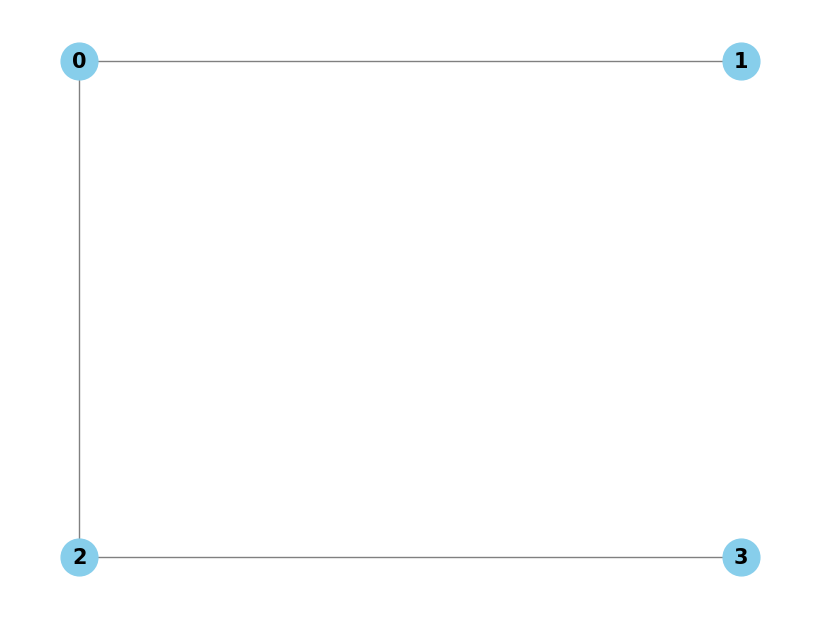

None

Sample Quantum Circuit (n_steps=1):


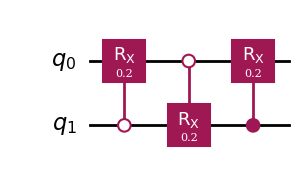


Detailed Gate Count Summary for Path Graph P3:
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 |  13/  6/    19              |   6/  2/     8             |   5/  2/     7            |   4/  2/     6
      2 |  26/ 12/    38              |   6/  2/     8             |  10/  4/    14            |   6/  2/     8
      5 |  65/ 30/    95              |   6/  2/     8             |  25/ 10/    35            |   6/  2/     8
     10 | 130/ 60/   190              |   6/  2/     8             |  50/ 20/    70            |   6/  2/     8
     20 | 260/120/   380              |   6/  2/     8             | 100/ 40/   140            |   6/  2/     8
     50 | 650/300/   950              |   6/  2/     8             | 250/100/   350            |   6/  2/     8
    100 | 1300/600/  1900          

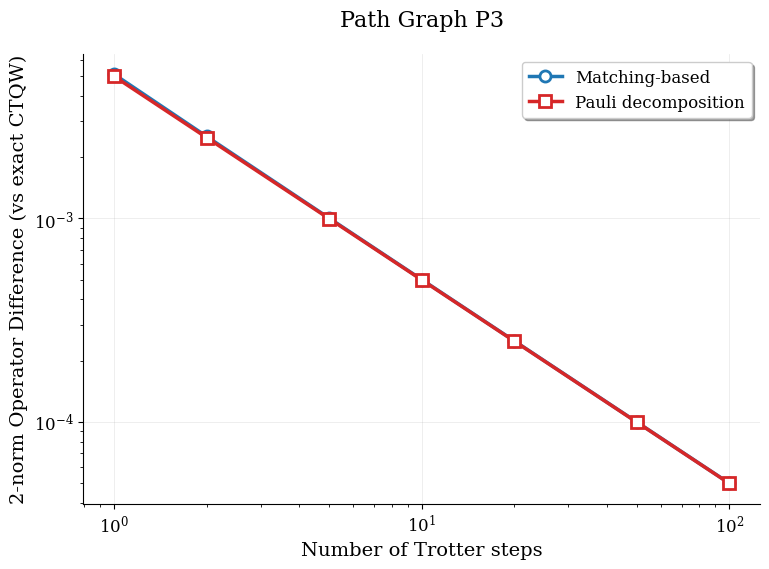

In [6]:
# Test Case 4: Multi-controlled rotation
def circuit_builder_4(n_qubits, n_steps, delta_t):
    full_qc = QuantumCircuit(n_qubits)
    for i in range(n_steps):
        mcrx1 = multi_crx(2 * delta_t/n_steps, '0')
        mcrx2 = multi_crx(2 * delta_t/n_steps, '1')
        
        full_qc.append(mcrx1, [1, 0])
        full_qc.append(mcrx1, [0, 1])
        full_qc.append(mcrx2, [1, 0])
    return full_qc

edges_4 = {('00', '01'), ('01', '10'), ('10', '11')}
relabeled_edges_4 = {('10', '11'), ('00', '10'), ('01', '00')}

analyze_and_plot(edges_4, relabeled_edges_4, circuit_builder_4, "Path Graph P3")